In [ ]:
# import torch
# print(torch.__version__)

# # !pip install torch_geometric
# import torch_geometric
# print(torch_geometric.__version__)

# # Optional dependencies:
# # !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cpu.html

# !pip install imblearn


In [ ]:
# !pip uninstall torch torchvision torchaudio -y
# !pip install torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0



In [ ]:
# 安装 代码

!pip uninstall torch_geometric pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -y

!pip install torch_geometric

# Optional dependencies:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 76.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 171.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 139.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.3 MB/s eta 0:00:00


### 安装 终端  


pip uninstall torch_geometric pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -y

pip install torch_geometric


pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

In [ ]:
import torch
import torch_geometric
print(torch.__version__)
print(torch.version.cuda)
print(torch_geometric.__version__)

 # 如果不报错，说明安装成功


/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sp

2.9.0+cpu
None
2.7.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 读取数据 剔除稀疏属性

In [ ]:
import torch
from torch_geometric.data import HeteroData
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ===================== 读取数据 =====================
all_df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/df_train.csv", low_memory=False)         # 全部就诊明细
label_df = pd.read_csv(r'/content/drive/MyDrive/Colab Notebooks/df_train_id3.csv', low_memory=False)   # 患者标签（是否欺诈）
print("[Info] 明细数据维度:", all_df.shape)
print("[Info] 标签数据维度:", label_df.shape)

# 清理列名
all_df = all_df.rename(columns=lambda x: x.strip())
label_df = label_df.rename(columns=lambda x: x.strip())

# 删除缺失主键
all_df = all_df.dropna(subset=['个人编码', '医院编码', '出院诊断病种名称'])
label_df = label_df.dropna(subset=['个人编码', '欺诈状态'])

# 确保 ID 类型一致
label_df['个人编码'] = label_df['个人编码'].astype(all_df['个人编码'].dtype)

# ===================== 原始候选特征 =====================
raw_feature_cols = [
    '药品费发生金额', '贵重药品发生金额', '中成药费发生金额', '中草药费发生金额',
    '药品费自费金额', '药品费拒付金额', '药品费申报金额',
    '检查费发生金额', '贵重检查费金额', '检查费自费金额', '检查费拒付金额', '检查费申报金额',
    '治疗费发生金额', '治疗费自费金额', '治疗费拒付金额', '治疗费申报金额',
    '手术费发生金额', '手术费自费金额', '手术费拒付金额', '手术费申报金额',
    '床位费发生金额', '床位费拒付金额', '床位费申报金额',
    '医用材料发生金额', '高价材料发生金额', '医用材料费自费金额', '医用材料费拒付金额',
    '输全血申报金额', '成分输血自费金额', '成分输血拒付金额', '成分输血申报金额',
    '其它发生金额', '其它拒付金额', '其它申报金额',
    '一次性医用材料自费金额', '一次性医用材料拒付金额', '一次性医用材料申报金额',
    '输全血按比例自负金额', '起付线标准金额', '起付标准以上自负比例金额',
    '医疗救助个人按比例负担金额', '最高限额以上金额', '统筹拒付金额', '基本医疗保险统筹基金支付金额',
    '城乡救助补助金额', '可用账户报销金额', '基本医疗保险个人账户支付金额', '非账户支付金额',
    '双笔退费标识', '本次审批金额', '补助审批金额', '医疗救助医院申请',
    '残疾军人医疗补助基金支付金额', '民政救助补助金额', '城乡优抚补助金额', '非典补助补助金额'
]
print("[Info] 原始候选特征数量:", len(raw_feature_cols))

all_df[raw_feature_cols] = all_df[raw_feature_cols].fillna(0)

# ===================== 稀疏特征剔除 =====================
print("\n=== 正在检查稀疏特征 ===")
threshold_feature = 1
valid_feature_cols = []
for col in raw_feature_cols:
    top_val = all_df[col].value_counts(normalize=True).idxmax()
    top_ratio = all_df[col].value_counts(normalize=True).values[0]
    if top_ratio >= threshold_feature:
        print(f"特征 '{col}' 被剔除（主值 = {top_val}，占比 {top_ratio:.2%}）")
    else:
        valid_feature_cols.append(col)

feature_cols = valid_feature_cols
print(f"✅ 保留特征数: {len(feature_cols)} / {len(raw_feature_cols)}")

# ===================== 拆分多疾病记录 =====================
all_df['出院诊断病种名称'] = all_df['出院诊断病种名称'].astype(str)

all_df['疾病列表'] = all_df['出院诊断病种名称'].apply(
    lambda x: [d.strip() for d in x.split(';') if d.strip()]
)

disease_expanded_df = all_df[['个人编码', '医院编码'] + feature_cols + ['疾病列表']].explode('疾病列表')
disease_expanded_df = disease_expanded_df.rename(columns={'疾病列表': '疾病名称'})

# 获取全部唯一疾病
disease_names = disease_expanded_df['疾病名称'].unique()
disease_id_to_idx = {name: i for i, name in enumerate(disease_names)}
print(f"[疾病ID映射] 共 {len(disease_id_to_idx)} 个疾病，示例: {list(disease_id_to_idx.items())[:5]}")


[Info] 明细数据维度: (1830386, 69)
[Info] 标签数据维度: (20000, 3)
[Info] 原始候选特征数量: 56

=== 正在检查稀疏特征 ===
⚠️ 特征 '药品费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '检查费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '治疗费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '手术费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '床位费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '医用材料费拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '输全血申报金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '成分输血自费金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '成分输血拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '其它拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '一次性医用材料自费金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '一次性医用材料拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '输全血按比例自负金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '最高限额以上金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '统筹拒付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '双笔退费标识' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '残疾军人医疗补助基金支付金额' 被剔除（主值 = 0.0，占比 100.00%）
⚠️ 特征 '非典补助补助金额' 被剔除（主值 = 0.0，占比 100.00%）
✅ 保留特征数: 38 / 56

=== 正在拆分多疾病记录 ===
[疾病ID映射] 共 17844 个疾病，示例: [('挂号', 0), ('尿毒症', 1), ('肾性贫血', 2), ('肾性高血压', 3), ('失眠', 4)]

=== 正在聚合患者特征 ===
[Info] 

### 构造基本图

In [ ]:
# ===================== 构造边：患者->医院，患者->疾病 =====================
patient_src_h, dst_hospital = [], []
patient_src_d, dst_disease = [], []

for i, pid in enumerate(all_ids):
    recs = all_df[all_df['个人编码'] == pid]
    for hid in recs['医院编码'].unique():
        patient_src_h.append(i)
        dst_hospital.append(hospital_id_to_idx[hid])

    recs_expanded = disease_expanded_df[disease_expanded_df['个人编码'] == pid]
    for dname in recs_expanded['疾病名称'].unique():
        patient_src_d.append(i)
        dst_disease.append(disease_id_to_idx[dname])
    

edge_index_ph = torch.tensor([patient_src_h, dst_hospital], dtype=torch.long)
edge_index_pd = torch.tensor([patient_src_d, dst_disease], dtype=torch.long)

# ===================== 构造边：医院->疾病 =====================
hospital_src_disease = []
disease_dst = []

for hid, dname in disease_expanded_df[['医院编码', '疾病名称']].drop_duplicates().values:
    hospital_src_disease.append(hospital_id_to_idx[hid])
    disease_dst.append(disease_id_to_idx[dname])

edge_index_hd = torch.tensor([hospital_src_disease, disease_dst], dtype=torch.long)

# ===================== 构建异构图 =====================
data = HeteroData()
data['patient'].x = torch.tensor(X_all, dtype=torch.float)
data['patient'].y = torch.tensor(y_all, dtype=torch.long)
data['patient'].train_mask = train_mask
data['patient'].test_mask = test_mask

data['hospital'].x = hospital_features
data['disease'].x = disease_features

# 添加边（正向和反向）
data['patient', 'visits', 'hospital'].edge_index = edge_index_ph
data['hospital', 'rev_visits', 'patient'].edge_index = edge_index_ph.flip(0)

data['patient', 'diagnosed_with', 'disease'].edge_index = edge_index_pd
data['disease', 'rev_diagnosed_with', 'patient'].edge_index = edge_index_pd.flip(0)

data['hospital', 'treats', 'disease'].edge_index = edge_index_hd
data['disease', 'rev_treats', 'hospital'].edge_index = edge_index_hd.flip(0)

print("=== 图构建完成 ===")
print(f"患者节点数: {data['patient'].num_nodes}")
print(f"医院节点数: {data['hospital'].num_nodes}")
print(f"疾病节点数: {data['disease'].num_nodes}")
print(f"患者-医院边数: {data['patient', 'visits', 'hospital'].num_edges}")
print(f"患者-疾病边数: {data['patient', 'diagnosed_with', 'disease'].num_edges}")
print(f"医院-疾病边数: {data['hospital', 'treats', 'disease'].num_edges}")


=== 图构建完成 ===
患者节点数: 10912
医院节点数: 425
疾病节点数: 17844
患者-医院边数: 20938
患者-疾病边数: 77632
医院-疾病边数: 22880
训练集标签分布: Counter({np.int64(1): 4200, np.int64(0): 2800})
测试集标签分布: Counter({np.int64(0): 3719, np.int64(1): 193})


In [ ]:
# ===================== 患者使用RFM特征 =====================
USE_NEW_PATIENT_FEATURES = True  # 切换开关：True=用新CSV特征，False=用原来的特征

if USE_NEW_PATIENT_FEATURES:
    new_feat_df = pd.read_csv("/content/drive/MyDrive/finalfeatures.csv") 

    # 第一列是个人编码，其余列是归一化后的特征
    pid_col = new_feat_df.columns[0]
    feature_cols_new = new_feat_df.columns[1:] 

    feat_matrix = []
    sample_cost_all = []
    missing_count = 0

    for pid in all_ids:
        row = new_feat_df.loc[new_feat_df[pid_col] == pid]
        if not row.empty:
            feat_matrix.append(row[feature_cols_new].values[0])
            sample_cost_all.append(row['总审批金额'].values[0])  # 提取成本
        else:
            feat_matrix.append(np.zeros(len(feature_cols_new)))
            sample_cost_all.append(0.0)
            missing_count += 1

    feat_matrix = np.array(feat_matrix, dtype=np.float32)
    sample_cost_all = np.array(sample_cost_all, dtype=np.float32)

    if missing_count > 0:
        print(f"新特征中缺少 {missing_count} 个患者，已用0填充")

    # 覆盖患者特征
    data['patient'].x = torch.tensor(feat_matrix, dtype=torch.float32)
    print(f"已替换患者特征，形状: {data['patient'].x.shape}")

else:
    print("\n=== 保留原有患者特征 ===")
    sample_cost_all = data['patient'].cost.cpu().numpy() if hasattr(data['patient'], 'cost') else np.zeros(data['patient'].num_nodes)



=== 正在加载新的患者特征CSV ===
✅ 已替换患者特征，形状: torch.Size([10912, 150])


In [ ]:
data

HeteroData(
  patient={
    x=[10912, 150],
    y=[10912],
    train_mask=[10912],
    test_mask=[10912],
  },
  hospital={ x=[425, 38] },
  disease={ x=[17844, 38] },
  (patient, visits, hospital)={ edge_index=[2, 20938] },
  (hospital, rev_visits, patient)={ edge_index=[2, 20938] },
  (patient, diagnosed_with, disease)={ edge_index=[2, 77632] },
  (disease, rev_diagnosed_with, patient)={ edge_index=[2, 77632] },
  (hospital, treats, disease)={ edge_index=[2, 22880] },
  (disease, rev_treats, hospital)={ edge_index=[2, 22880] }
)

In [ ]:
import torch
from torch_geometric.data import HeteroData

def add_new_coupling_nodes(data: HeteroData):
    """
    在已有的异质图上添加四类二元耦合节点：
    1. HD 节点: (医院, 疾病)，与患者相连
    2. PD 节点: (患者, 疾病)，与医院相连
    3. PH 节点: (患者, 医院)，与疾病相连
    4. PP 节点: (患者1, 患者2)，共享医院或疾病

    特征拼接方式：
    - 节点ID和出现次数用 torch.tensor([..]) 放在最前面
    - 实际特征用 torch.cat 拼接
    """

    edge_PH = data['patient', 'visits', 'hospital'].edge_index
    edge_PD = data['patient', 'diagnosed_with', 'disease'].edge_index

    # ========== 1. HD ==========
    hd_nodes, hd_edges_to_p, hd_x = [], [[], []], []
    for p in torch.unique(edge_PH[0]):
        hospitals = edge_PH[1][edge_PH[0] == p]
        diseases = edge_PD[1][edge_PD[0] == p]
        for h in hospitals.tolist():
            for d in diseases.tolist():
                count = min(
                    ((edge_PH[0] == p) & (edge_PH[1] == h)).sum().item(),
                    ((edge_PD[0] == p) & (edge_PD[1] == d)).sum().item()
                )
                idx = len(hd_nodes)
                hd_nodes.append((p.item(), h, d))
                hd_edges_to_p[0].append(idx)
                hd_edges_to_p[1].append(p.item())
                hd_x.append(torch.cat([
                    torch.tensor([h, d, count], dtype=torch.float),
                    data['hospital'].x[h],
                    data['disease'].x[d]
                ]))
    data['hd'].x = torch.stack(hd_x) if hd_x else torch.zeros((0, 1))
    data['hd'].num_nodes = len(hd_nodes)
    data['hd', 'connects', 'patient'].edge_index = torch.tensor(hd_edges_to_p)

    # ========== 2. PD ==========
    pd_nodes, pd_edges_to_h, pd_x = [], [[], []], []
    for p in torch.unique(edge_PD[0]):
        diseases = edge_PD[1][edge_PD[0] == p]
        for d in diseases.tolist():
            idx = len(pd_nodes)
            pd_nodes.append((p.item(), d))
            hospitals = edge_PH[1][edge_PH[0] == p]
            for h in hospitals.tolist():
                pd_edges_to_h[0].append(idx)
                pd_edges_to_h[1].append(h)
            pd_x.append(torch.cat([
                torch.tensor([p.item(), d], dtype=torch.float),
                data['patient'].x[p],
                data['disease'].x[d]
            ]))
    data['pd'].x = torch.stack(pd_x) if pd_x else torch.zeros((0, 1))
    data['pd'].num_nodes = len(pd_nodes)
    data['pd', 'connects', 'hospital'].edge_index = torch.tensor(pd_edges_to_h)

    # ========== 3. PH ==========
    ph_nodes, ph_edges_to_d, ph_x = [], [[], []], []
    for p in torch.unique(edge_PH[0]):
        hospitals = edge_PH[1][edge_PH[0] == p]
        for h in hospitals.tolist():
            idx = len(ph_nodes)
            ph_nodes.append((p.item(), h))
            diseases = edge_PD[1][edge_PD[0] == p]
            for d in diseases.tolist():
                ph_edges_to_d[0].append(idx)
                ph_edges_to_d[1].append(d)
            ph_x.append(torch.cat([
                torch.tensor([p.item(), h], dtype=torch.float),
                data['patient'].x[p],
                data['hospital'].x[h]
            ]))
    data['ph'].x = torch.stack(ph_x) if ph_x else torch.zeros((0, 1))
    data['ph'].num_nodes = len(ph_nodes)
    data['ph', 'connects', 'disease'].edge_index = torch.tensor(ph_edges_to_d)

    # ========== 4. HH ==========
    # hh_nodes, hh_edges_to_p, hh_edges_to_d, hh_x = [], [[], []], [[], []], []
    # for p in torch.unique(edge_PH[0]):
    #     hospitals = edge_PH[1][edge_PH[0] == p].tolist()
    #     for i in range(len(hospitals)):
    #         for j in range(i+1, len(hospitals)):
    #             h1, h2 = hospitals[i], hospitals[j]
    #             idx = len(hh_nodes)
    #             hh_nodes.append((p.item(), h1, h2))
    #             hh_edges_to_p[0].append(idx)
    #             hh_edges_to_p[1].append(p.item())
    #             for d in edge_PD[1][edge_PD[0] == p].tolist():
    #                 hh_edges_to_d[0].append(idx)
    #                 hh_edges_to_d[1].append(d)
    #             hh_x.append(torch.cat([
    #                 torch.tensor([h1, h2], dtype=torch.float),
    #                 data['hospital'].x[h1],
    #                 data['hospital'].x[h2]
    #             ]))
    # data['hh'].x = torch.stack(hh_x) if hh_x else torch.zeros((0, 1))
    # data['hh'].num_nodes = len(hh_nodes)
    # data['hh', 'connects', 'patient'].edge_index = torch.tensor(hh_edges_to_p)
    # data['hh', 'connects', 'disease'].edge_index = torch.tensor(hh_edges_to_d)

    # ========== 5. PP ==========
    pp_nodes, pp_edges_to_h, pp_edges_to_d, pp_x = [], [[], []], [[], []], []
    patients = torch.unique(edge_PH[0])
    for i in range(len(patients)):
        for j in range(i+1, len(patients)):
            p1, p2 = patients[i].item(), patients[j].item()
            common_h = list(set(edge_PH[1][edge_PH[0]==p1].tolist()) &
                            set(edge_PH[1][edge_PH[0]==p2].tolist()))
            common_d = list(set(edge_PD[1][edge_PD[0]==p1].tolist()) &
                            set(edge_PD[1][edge_PD[0]==p2].tolist()))
            if not common_h and not common_d:
                continue
            idx = len(pp_nodes)
            pp_nodes.append((p1, p2))
            for h in common_h:
                pp_edges_to_h[0].append(idx)
                pp_edges_to_h[1].append(h)
            for d in common_d:
                pp_edges_to_d[0].append(idx)
                pp_edges_to_d[1].append(d)
            pp_x.append(torch.cat([
                torch.tensor([p1, p2], dtype=torch.float),
                data['patient'].x[p1],
                data['patient'].x[p2]
            ]))
    data['pp'].x = torch.stack(pp_x) if pp_x else torch.zeros((0, 1))
    data['pp'].num_nodes = len(pp_nodes)
    data['pp', 'connects', 'hospital'].edge_index = torch.tensor(pp_edges_to_h)
    data['pp', 'connects', 'disease'].edge_index = torch.tensor(pp_edges_to_d)

    # ========== 6. DD ==========
    # dd_nodes, dd_edges_to_p, dd_x = [], [[], []], []
    # for p in torch.unique(edge_PD[0]):
    #     diseases = edge_PD[1][edge_PD[0]==p].tolist()
    #     for i in range(len(diseases)):
    #         for j in range(i+1, len(diseases)):
    #             d1, d2 = diseases[i], diseases[j]
    #             idx = len(dd_nodes)
    #             dd_nodes.append((d1, d2))
    #             dd_edges_to_p[0].append(idx)
    #             dd_edges_to_p[1].append(p.item())
    #             dd_x.append(torch.cat([
    #                 torch.tensor([d1, d2], dtype=torch.float),
    #                 data['disease'].x[d1],
    #                 data['disease'].x[d2]
    #             ]))
    # data['dd'].x = torch.stack(dd_x) if dd_x else torch.zeros((0, 1))
    # data['dd'].num_nodes = len(dd_nodes)
    # data['dd', 'connects', 'patient'].edge_index = torch.tensor(dd_edges_to_p)

    # ========== rev ==========
    data['patient','rev_connects','hd'].edge_index = data['hd','connects','patient'].edge_index.flip(0)
    data['hospital','rev_connects','pd'].edge_index = data['pd','connects','hospital'].edge_index.flip(0)
    data['disease','rev_connects','ph'].edge_index = data['ph','connects','disease'].edge_index.flip(0)
    # data['patient','rev_connects','hh'].edge_index = data['hh','connects','patient'].edge_index.flip(0)
    # data['disease','rev_connects','hh'].edge_index = data['hh','connects','disease'].edge_index.flip(0)

    # 新增反向
    data['hospital','rev_connects','pp'].edge_index = data['pp','connects','hospital'].edge_index.flip(0)
    data['disease','rev_connects','pp'].edge_index = data['pp','connects','disease'].edge_index.flip(0)
    # data['patient','rev_connects','dd'].edge_index = data['dd','connects','patient'].edge_index.flip(0)

    return data


# 调用
data = add_new_coupling_nodes(data)
print(data.metadata())

In [ ]:
data

HeteroData(
  patient={
    x=[10912, 150],
    y=[10912],
    train_mask=[10912],
    test_mask=[10912],
  },
  hospital={ x=[425, 38] },
  disease={ x=[17844, 38] },
  hd={
    x=[184283, 79],
    num_nodes=184283,
  },
  pd={
    x=[77632, 191],
    num_nodes=77632,
  },
  ph={
    x=[20938, 191],
    num_nodes=20938,
  },
  hh={
    x=[15828, 79],
    num_nodes=15828,
  },
  (patient, visits, hospital)={ edge_index=[2, 20938] },
  (hospital, rev_visits, patient)={ edge_index=[2, 20938] },
  (patient, diagnosed_with, disease)={ edge_index=[2, 77632] },
  (disease, rev_diagnosed_with, patient)={ edge_index=[2, 77632] },
  (hospital, treats, disease)={ edge_index=[2, 22880] },
  (disease, rev_treats, hospital)={ edge_index=[2, 22880] },
  (hospital, co_visit, hospital)={ edge_index=[2, 19370] },
  (disease, co_diagnose, disease)={ edge_index=[2, 478136] },
  (hd, connects, patient)={ edge_index=[2, 184283] },
  (pd, connects, hospital)={ edge_index=[2, 184283] },
  (ph, connects, dise

### Savings Metric

In [ ]:

def savings(probs, labels, sample_cost, thresh, check_cost, Lambda):
     # 转换为 numpy 数组（兼容 tensor）
    probs = probs.cpu().detach().numpy() if hasattr(probs, 'cpu') else np.asarray(probs)
    labels = labels.cpu().detach().numpy() if hasattr(labels, 'cpu') else np.asarray(labels)
    sample_cost = sample_cost.cpu().detach().numpy() if hasattr(sample_cost, 'cpu') else np.asarray(sample_cost)


     # ==============  计算savings ===================
    predictions = (probs >= thresh).astype(int)
    N = len(labels)

    # 构建每个样本的 cost_matrix: shape = [N, 2, 2]
    cost_matrix = np.zeros((N, 2, 2))

    # cost_matrix[:, pred, label]
    # 无检查（预测为0）
    cost_matrix[:, 0, 0] = 0                              # TN: 无损失无检查
    cost_matrix[:, 0, 1] = sample_cost.flatten()                    # FN: 无检查但有损失

    # 有检查（预测为1）
    cost_matrix[:, 1, 0] = check_cost                     # FP: 有检查无损失
    cost_matrix[:, 1, 1] = check_cost * Lambda            # TP: 有检查有损失，损失按Lambda加权

    # 使用算法的成本
    cost_tn = cost_matrix[:, 0, 0][(predictions == 0) & (labels == 0)].sum()
    cost_fn = cost_matrix[:, 0, 1][(predictions == 0) & (labels == 1)].sum()
    cost_fp = cost_matrix[:, 1, 0][(predictions == 1) & (labels == 0)].sum()
    cost_tp = cost_matrix[:, 1, 1][(predictions == 1) & (labels == 1)].sum()
    cost_with = cost_tn + cost_fn + cost_fp + cost_tp

    # 不使用算法的成本（全为0或全为1中最小的那种）
    cost_neg = cost_matrix[:, 0, 0][labels == 0].sum() + cost_matrix[:, 0, 1][labels == 1].sum()
    cost_pos = cost_matrix[:, 1, 0][labels == 0].sum() + cost_matrix[:, 1, 1][labels == 1].sum()
    cost_without = min(cost_neg, cost_pos)

    savings_value = 1 - cost_with / cost_without

    print(f"thresh={thresh:.3f},checkcost={check_cost}, cost_fn={cost_fn:.3f}, cost_fp={cost_fp:.3f}, cost_tp={cost_tp:.3f}, "
          f"cost_with={cost_with:.3f}, cost_without={cost_without:.3f}, savings={savings_value:.4f}, cost_all_pos={cost_pos:.4f}, cost_all_neg={cost_neg:.4f}")


    # ==========  算阈值 ==================================
    total_pos_cost = sample_cost[labels == 1].sum()
    num_neg = (labels == 0).sum()
    num_pos = (labels == 1).sum()
    print(f"有标签为0的样本总数：{num_neg}")
    print(f"有标签为1的样本总数：{num_pos}")

    middle_thresh = sample_cost[labels == 1].sum() / ((labels == 0).sum() + (labels == 1).sum() * Lambda)
    print(f"middle_threash: {middle_thresh:.4f}")

    thresh_1 = (sample_cost[labels == 1].sum() - sample_cost[(labels == 1) & (predictions == 0)].sum()) / (Lambda * ((labels == 1) & (predictions == 1)).sum() + ((labels == 0) & (predictions == 1)).sum())
    print(f"{middle_thresh:.4f} < check < {thresh_1:.4f}")

    thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (
    (Lambda * (labels==1).sum() + (labels==0).sum()) *
    (Lambda * ((labels==1) & (predictions==0)).sum() + ((labels==0) & (predictions==0)).sum())
)

    print(f"{thresh_2:.4f} < check < {middle_thresh:.4f}")
    return savings_value




## COST_BCE 损失函数

In [ ]:
def hybrid_cost_bce_loss(probs, labels, sample_cost, check_cost,
                         Lambda=0.8, alpha=0.01, mode='cost_bce', eps=1e-8):
    """
    改良版混合成本敏感 BCE 损失
    -----------------------------
    probs: tensor [N] 预测概率 (sigmoid 输出)
    labels: tensor [N] 标签 0/1
    sample_cost: tensor [N] 每个样本的损失成本
    check_cost: scalar，检查成本
    Lambda: 权衡阳性样本检查成本
    alpha: hybrid模式下BCE占比
    mode: 'cost_bce' 或 'hybrid'
    eps: 防止除零
    """
    labels = labels.float()
    probs = probs.float()

    # ---------- Cost-weighted 部分 ----------
    # 按规则计算每个样本的成本
    weight = labels * (Lambda * check_cost * probs + sample_cost * (1 - probs)) + \
             (1 - labels) * (check_cost * probs)

    # 避免数量级过大
    weight = weight / (weight.mean() + eps)

    # ---------- BCE ----------
    bce = F.binary_cross_entropy(probs, labels, reduction='none')

    if mode == 'cost_bce':
        # 加权 BCE
        loss = (bce * weight).mean()
    elif mode == 'hybrid':
        # 混合 BCE + cost
        cost_term = weight
        loss = alpha * bce.mean() + (1 - alpha) * cost_term.mean()
    else:
        raise ValueError("mode 必须为 'cost_bce' 或 'hybrid'")

    return loss

## HAN+单次训练

[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 7000
Test mask sum: 3912

Epoch 001 - 平均元路径注意力:
  P-H-P: 0.09824572
  P-D-P: 0.08800095
  D-P-D: 0.09320550
  H-P-H: 0.09435321
  P1-H1-P2-H2: 0.08480103
  P1-D1-P2-D2: 0.08150125
  P1-HD-P2: 0.08836780
  H1-PD-H2: 0.08836780
  PH1-D-PH2: 0.08836780
  HH1-D-HH2: 0.08836780
  HD1-P-HD2: 0.10642115

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5107, 最大值: 0.5488, 均值: 0.5191
[真实为1] 样本数: 4393, 最小值: 0.5131, 最大值: 0.5608, 均值: 0.5254
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6894 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7428
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipykernel_8099/1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P-H-P: 0.04472091
  P-D-P: 0.09153148
  D-P-D: 0.11673804
  H-P-H: 0.04529824
  P1-H1-P2-H2: 0.04892034
  P1-D1-P2-D2: 0.18020174
  P1-HD-P2: 0.05641367
  H1-PD-H2: 0.05641367
  PH1-D-PH2: 0.05641367
  HH1-D-HH2: 0.05641367
  HD1-P-HD2: 0.24693458

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5990, 最大值: 0.9506, 均值: 0.6698
[真实为1] 样本数: 4393, 最小值: 0.6257, 最大值: 0.9906, 均值: 0.7559
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.5132 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8177
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipykernel_8099/1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P-H-P: 0.00665768
  P-D-P: 0.02947077
  D-P-D: 0.03674459
  H-P-H: 0.00805691
  P1-H1-P2-H2: 0.00734275
  P1-D1-P2-D2: 0.06625842
  P1-HD-P2: 0.05087680
  H1-PD-H2: 0.05087680
  PH1-D-PH2: 0.05087680
  HH1-D-HH2: 0.05087680
  HD1-P-HD2: 0.64196169

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5182, 最大值: 0.8758, 均值: 0.5668
[真实为1] 样本数: 4393, 最小值: 0.5881, 最大值: 0.9569, 均值: 0.7297
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.4377 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.9785
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipykernel_8099/1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P-H-P: 0.00086133
  P-D-P: 0.00489933
  D-P-D: 0.00620457
  H-P-H: 0.00105709
  P1-H1-P2-H2: 0.00096957
  P1-D1-P2-D2: 0.01307475
  P1-HD-P2: 0.02409765
  H1-PD-H2: 0.02409765
  PH1-D-PH2: 0.02409765
  HH1-D-HH2: 0.02409765
  HD1-P-HD2: 0.87654281

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3449, 最大值: 0.8565, 均值: 0.4980
[真实为1] 样本数: 4393, 最小值: 0.6628, 最大值: 0.9717, 均值: 0.8074
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=117.420, cost_tp=210.864, cost_with=328.284, cost_without=602.004, savings=0.4547, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.1268
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.3370 | Acc: 0.8207 | Precision: 0.6918 | Recall: 1.0000 | F1: 0.8178 | ROC AUC: 0.9982
Confusion Matrix:
 [[4562 1957]
 [   0 4393]]
Savings: 0.4547

Epoch 040 - 平均元路径注意力:
  P-H-P: 0.00017554
  P-D-P: 0.00100905
  D-P-D: 0.00132779
  H-P-H: 0.00020508
  P1-H1-P2-H2: 0.00019744
  P1-D1-P2-D2:

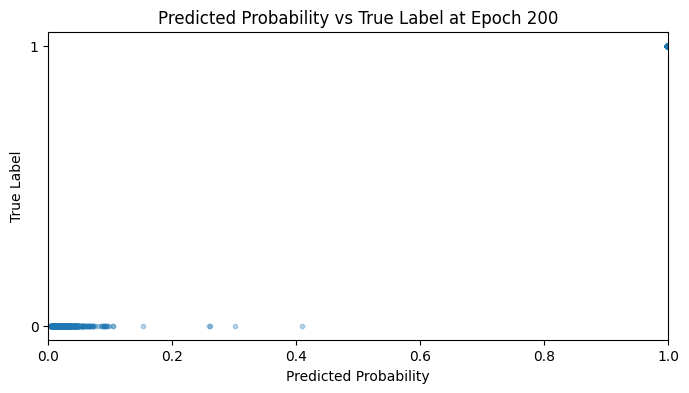

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GATConv
from torch.nn import Parameter

class HANLayer(torch.nn.Module):
    def __init__(self, metadata, metapaths, hidden_channels, num_gat_layers=1, heads=1, concat=True):
        super().__init__()
        self.metapaths = metapaths
        self.hidden_channels = hidden_channels
        self.num_gat_layers = num_gat_layers
        self.heads = heads
        self.concat = concat

        self.metapath_convs = torch.nn.ModuleList()
        for metapath in metapaths:
            layers = torch.nn.ModuleList()
            edge_types = []
            for i in range(1, len(metapath)-1, 2):
                edge_types.append((metapath[i-1], metapath[i], metapath[i+1]))

            for _ in range(num_gat_layers):
                conv = HeteroConv({
                    etype: GATConv(
                        (-1, -1),
                        hidden_channels,
                        heads=heads,
                        concat=concat,
                        add_self_loops=False
                    )
                    for etype in edge_types
                }, aggr='mean')
                layers.append(conv)
            self.metapath_convs.append(layers)

        out_dim = hidden_channels * heads if concat else hidden_channels
        self.metapath_att = Parameter(torch.Tensor(len(metapaths), out_dim))
        torch.nn.init.xavier_uniform_(self.metapath_att)

    def forward(self, x_dict, edge_index_dict):
        patient_outs = []
        for i, layers in enumerate(self.metapath_convs):
            # 拷贝 x_dict 避免覆盖
            x = {k: v.clone() for k, v in x_dict.items()}

            for conv in layers:
                # 防止 conv 输出为空，先检查
                if len(x) == 0:
                    break
                x = conv(x, edge_index_dict)
                x = {k: F.elu(v) for k, v in x.items()}

            # 获取 patient embedding
            if 'patient' in x:
                last_emb = x['patient']
            else:
                # 无 patient 输出时，用 x_dict['patient'] 的 shape 初始化
                num_patient = x_dict['patient'].shape[0]
                hidden_dim = self.hidden_channels * self.heads if self.concat else self.hidden_channels
                device = list(x_dict.values())[0].device
                last_emb = torch.zeros((num_patient, hidden_dim), device=device)

            patient_outs.append(last_emb)

        metapath_stack = torch.stack(patient_outs, dim=0)  # [num_metapath, num_patient, hidden]
        att_scores = (metapath_stack * self.metapath_att.unsqueeze(1)).sum(dim=-1)
        att_weights = F.softmax(att_scores, dim=0)

        self.last_att_weights = att_weights.detach().cpu()  #  保存元路径注意力矩阵
        self.last_metapath_names = getattr(self, 'metapath_names', None)  # 记录名字方便后续使用


        weighted_sum = (att_weights.unsqueeze(-1) * metapath_stack).sum(dim=0)

        return weighted_sum, att_weights


class HANModel(torch.nn.Module):
    def __init__(self, metadata, metapaths, hidden_channels=64, out_channels=1, num_gat_layers=1, heads=1, concat=True):
        super().__init__()
        self.han_layer = HANLayer(metadata, metapaths, hidden_channels, num_gat_layers, heads, concat)
        in_dim = hidden_channels * heads if concat else hidden_channels
        self.lin = torch.nn.Linear(in_dim, out_channels)

    def forward(self, data):
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        patient_emb, att_weights = self.han_layer(x_dict, edge_index_dict)
        logits = self.lin(patient_emb).squeeze(-1)
        probs = torch.sigmoid(logits)
        return probs, logits, att_weights


import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def train_and_evaluate(
    model,
    data,
    train_mask,
    test_mask,
    sample_cost_np=None,
    sample_cost_train=None,
    optimizer=None,
    loss_fn=None,
    device='cpu',
    epochs=100,
    threshold=0.5,
    check_cost=280.9,
    Lambda=0.8,
    metapaths=None,
    metapath_names=None,
    savings=None
):
    model.to(device)
    data = data.to(device)
    labels = data['patient'].y.to(device)
    train_mask = train_mask.to(device)
    test_mask = test_mask.to(device)

    print(f"[INFO] Using device: {device}")
    print("Labels unique:", torch.unique(labels))
    print("Train mask sum:", train_mask.sum().item())
    print("Test mask sum:", test_mask.sum().item())

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        probs, logits, _ = model(data)

        if type(loss_fn).__name__ == 'function' and loss_fn.__name__ in ['cost_sensitive_loss','hybrid_cost_bce_loss']:
            loss = loss_fn(
                probs[train_mask],
                labels[train_mask],
                sample_cost_train,  # 训练集 cost
                check_cost,
                Lambda
            )
        else:
            loss = loss_fn(probs[train_mask], labels[train_mask].float())

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                probs, logits, att_weights = model(data)
                preds = (probs >= threshold).long()

                labels_np = labels.cpu().numpy()
                preds_np = preds.cpu().numpy()
                probs_np = probs.cpu().numpy()
                sample_cost_np = sample_cost_full

                # 打印元路径注意力
                weights = att_weights.mean(dim=1).cpu().numpy()  # 平均每条元路径的 attention
                print(f"\nEpoch {epoch:03d} - 平均元路径注意力:")
                for i, w in enumerate(weights):
                    name = metapath_names[i] if metapath_names and i < len(metapath_names) else f"Metapath-{i}"
                    print(f"  {name}: {w:.8f}")

                # 概率分布分析
                probs_true_0 = probs_np[labels_np == 0]
                probs_true_1 = probs_np[labels_np == 1]
                print("\n=== 概率分布分析（测试集） ===")
                if len(probs_true_0) > 0:
                    print(f"[真实为0] 样本数: {len(probs_true_0)}, 最小值: {probs_true_0.min():.4f}, 最大值: {probs_true_0.max():.4f}, 均值: {probs_true_0.mean():.4f}")
                if len(probs_true_1) > 0:
                    print(f"[真实为1] 样本数: {len(probs_true_1)}, 最小值: {probs_true_1.min():.4f}, 最大值: {probs_true_1.max():.4f}, 均值: {probs_true_1.mean():.4f}")

                # 计算指标
                acc = accuracy_score(labels_np, preds_np)
                precision = precision_score(labels_np, preds_np, zero_division=0)
                recall = recall_score(labels_np, preds_np, zero_division=0)
                f1 = f1_score(labels_np, preds_np, zero_division=0)
                cm = confusion_matrix(labels_np, preds_np)

                try:
                    roc_auc = roc_auc_score(labels_np, probs_np)
                except ValueError:
                    roc_auc = float('nan')

                if savings is not None and sample_cost_np is not None:
                    savings_score = savings(thresh=threshold, probs=probs_np, labels=labels_np,
                                           sample_cost=sample_cost_np, check_cost=check_cost, Lambda=Lambda)
                else:
                    savings_score = float('nan')

                print(f"\nEpoch {epoch:03d} | Loss: {loss.item():.4f} | Acc: {acc:.4f} | "
                      f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}")
                print("Confusion Matrix:\n", cm)
                print(f"Savings: {savings_score:.4f}")


    # 保存元路径权重矩阵到模型中
    if hasattr(model, "han_layer") and hasattr(model.han_layer, "last_att_weights"):
      model.att_weights_matrix = model.han_layer.last_att_weights.numpy()
      print("\n[INFO] 元路径权重矩阵已保存: shape =", model.att_weights_matrix.shape)

    # 可视化概率分布（最后一个 epoch）
    plt.figure(figsize=(8,4))
    plt.scatter(probs_np, labels_np, alpha=0.3, s=10)
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Label")
    plt.title(f"Predicted Probability vs True Label at Epoch {epoch}")
    plt.yticks([0, 1])
    plt.xlim(0, 1)
    plt.show()


import torch
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GATConv
from torch.nn import Parameter
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


THRESHOLD = 0.5

import torch
# torch.cuda.empty_cache()
metapath = [
    # Direct Identification
    ("patient", "visits", "hospital", "rev_visits", "patient"),                 # P-H-P
    ("patient", "diagnosed_with", "disease", "rev_diagnosed_with", "patient"),   # P-D-P
    ("patient", "rev_connects", "hd", "connects", "patient"),                    # P-HD-P

    # Group Identification
    ("pp", "connects", "hospital", "rev_connects", "pp"),                        # PP-H-PP
    ("pp", "connects", "disease", "rev_connects", "pp"),                        # PP-D-PP
    ("ph", "connects", "disease", "rev_connects", "ph"),                        # PH-D-PH

    # Enhanced Inference
    ("disease", "rev_diagnosed_with", "patient", "diagnosed_with", "disease"),   # D-P-D
    ("hospital", "rev_visits", "patient", "visits", "hospital"),                 # H-P-H
    ("hospital", "rev_connects", "pd", "connects", "hospital"),                  # H-PD-H
    ("disease", "rev_connects", "ph", "connects", "disease"),                   # D-PH-D
]

metapath_names = [
    "P-H-P", "P-D-P", "P-HD-P",
    "PP-H-PP", "PP-D-PP", "PH-D-PH",
    "D-P-D", "H-P-H", "H-PD-H", "D-PH-D"
]

# ======= 设备和模型初始化 =======
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_CE = HANModel(
    metadata=data.metadata,
    metapaths=metapaths,
    hidden_channels=64,
    heads = 4,
    concat = True,
    out_channels=1,
    num_gat_layers=2
).to(DEVICE)


train_and_evaluate(
    model=model_CE,
    data=data,
    train_mask=data['patient'].train_mask,
    test_mask=data['patient'].test_mask,
    sample_cost_np=sample_cost_test,     
    sample_cost_train=sample_cost_train,  
    optimizer=optimizer_CE,
    # loss_fn=torch.nn.BCELoss(), # BCE LOSS
    loss_fn=hybrid_cost_bce_loss, # COST-BCE LOSS
    device=DEVICE,
    metapaths=metapaths,
    metapath_names=metapath_names,
    savings=savings,
    epochs=500,
    threshold=0.5,
    check_cost=0.06,
    Lambda=0.8
)


## 十折检验


===== Fold 1/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9820
Test mask sum: 1092

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.16435207
  P1-H1-P2-H2: 0.18300472
  P-D-P: 0.15958700
  H1-PD-H2: 0.16435207
  PH1-D-PH2: 0.16435207
  HH1-D-HH2: 0.16435207

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5101, 最大值: 0.5298, 均值: 0.5157
[真实为1] 样本数: 4393, 最小值: 0.5102, 最大值: 0.5305, 均值: 0.5177
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6904 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7030
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.11065609
  P1-H1-P2-H2: 0.21125078
  P-D-P: 0.34612486
  H1-PD-H2: 0.11065609
  PH1-D-PH2: 0.11065609
  HH1-D-HH2: 0.11065609

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5586, 最大值: 0.7973, 均值: 0.6191
[真实为1] 样本数: 4393, 最小值: 0.5711, 最大值: 0.8528, 均值: 0.6660
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6298 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7623
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.10625973
  P1-H1-P2-H2: 0.04598037
  P-D-P: 0.52898079
  H1-PD-H2: 0.10625973
  PH1-D-PH2: 0.10625973
  HH1-D-HH2: 0.10625973

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5177, 最大值: 0.7733, 均值: 0.5627
[真实为1] 样本数: 4393, 最小值: 0.5335, 最大值: 0.8536, 均值: 0.6339
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5857 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8386
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.08847376
  P1-H1-P2-H2: 0.02006347
  P-D-P: 0.62604153
  H1-PD-H2: 0.08847376
  PH1-D-PH2: 0.08847376
  HH1-D-HH2: 0.08847376

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4299, 最大值: 0.8110, 均值: 0.5312
[真实为1] 样本数: 4393, 最小值: 0.4967, 最大值: 0.9302, 均值: 0.6383
thresh=0.500,checkcost=0.06, cost_fn=0.068, cost_fp=297.780, cost_tp=210.768, cost_with=508.616, cost_without=602.004, savings=0.1551, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0819
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5559 | Acc: 0.5450 | Precision: 0.4694 | Recall: 0.9995 | F1: 0.6388 | ROC AUC: 0.8704
Confusion Matrix:
 [[1556 4963]
 [   2 4391]]
Savings: 0.1551

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.04943037
  P1-H1-P2-H2: 0.00924250
  P-D-P: 0.79303604
  H1-PD-H2: 0.04943037
  PH1-D-PH2: 0.04943037
  HH1-D-HH2: 0.04943037

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.2220, 最大值: 0.8522, 均值: 0.4825
[真实为1] 样本数: 43

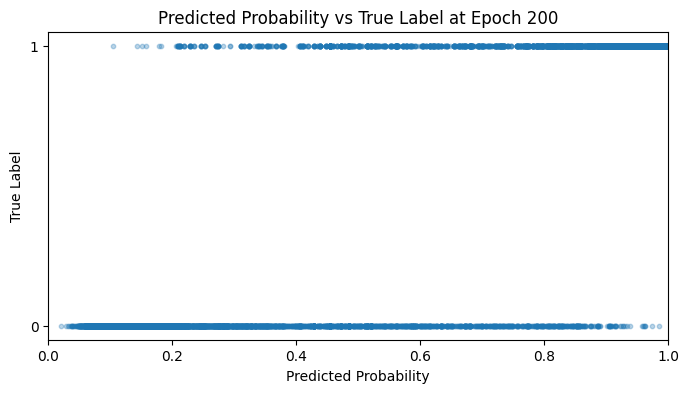


===== Fold 2/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9820
Test mask sum: 1092

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.16135436
  P1-H1-P2-H2: 0.18219948
  P-D-P: 0.17238301
  H1-PD-H2: 0.16135436
  PH1-D-PH2: 0.16135436
  HH1-D-HH2: 0.16135436

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4941, 最大值: 0.5219, 均值: 0.5007
[真实为1] 样本数: 4393, 最小值: 0.4952, 最大值: 0.5242, 均值: 0.5035
thresh=0.500,checkcost=0.06, cost_fn=55.682, cost_fp=199.260, cost_tp=155.472, cost_with=410.414, cost_without=602.004, savings=0.3183, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.1080
0.0000 < check < 0.0692

Epoch 001 | Loss: 0.7021 | Acc: 0.5899 | Precision: 0.4938 | Recall: 0.7373 | F1: 0.5914 | ROC AUC: 0.7013
Confusion Matrix:
 [[3198 3321]
 [1154 3239]]
Savings: 0.3183

Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.10006832
  P1-H1-P2-H2: 0.18426581
  P-D-P: 0.41546094
  H1-PD-H2: 0.10006832


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.10848611
  P1-H1-P2-H2: 0.04483048
  P-D-P: 0.52122504
  H1-PD-H2: 0.10848611
  PH1-D-PH2: 0.10848611
  HH1-D-HH2: 0.10848611

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5062, 最大值: 0.7736, 均值: 0.5542
[真实为1] 样本数: 4393, 最小值: 0.5231, 最大值: 0.8509, 均值: 0.6284
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5811 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8334
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.09585803
  P1-H1-P2-H2: 0.01931098
  P-D-P: 0.59725690
  H1-PD-H2: 0.09585803
  PH1-D-PH2: 0.09585803
  HH1-D-HH2: 0.09585803

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4583, 最大值: 0.8106, 均值: 0.5294
[真实为1] 样本数: 4393, 最小值: 0.4948, 最大值: 0.9149, 均值: 0.6337
thresh=0.500,checkcost=0.06, cost_fn=0.068, cost_fp=284.700, cost_tp=210.768, cost_with=495.536, cost_without=602.004, savings=0.1769, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0840
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5557 | Acc: 0.5650 | Precision: 0.4806 | Recall: 0.9995 | F1: 0.6491 | ROC AUC: 0.8658
Confusion Matrix:
 [[1774 4745]
 [   2 4391]]
Savings: 0.1769

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.07449723
  P1-H1-P2-H2: 0.01096020
  P-D-P: 0.69105089
  H1-PD-H2: 0.07449723
  PH1-D-PH2: 0.07449723
  HH1-D-HH2: 0.07449723

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3422, 最大值: 0.8397, 均值: 0.4978
[真实为1] 样本数: 43

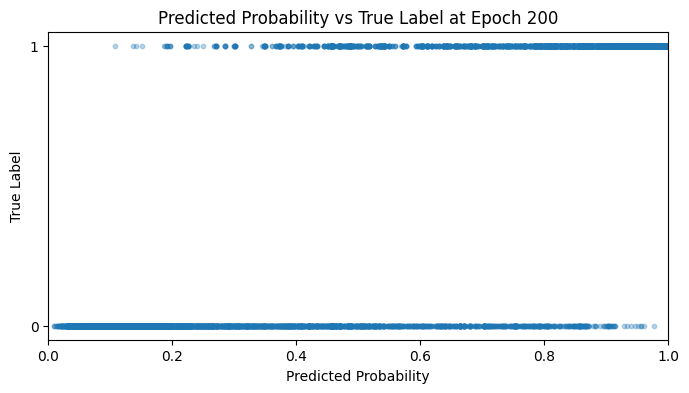


===== Fold 3/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.15481117
  P1-H1-P2-H2: 0.23600098
  P-D-P: 0.14475426
  H1-PD-H2: 0.15481117
  PH1-D-PH2: 0.15481117
  HH1-D-HH2: 0.15481117

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5061, 最大值: 0.5559, 均值: 0.5160
[真实为1] 样本数: 4393, 最小值: 0.5088, 最大值: 0.5572, 均值: 0.5196
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6900 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.6983
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.10816461
  P1-H1-P2-H2: 0.24070805
  P-D-P: 0.32663354
  H1-PD-H2: 0.10816461
  PH1-D-PH2: 0.10816461
  HH1-D-HH2: 0.10816461

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5451, 最大值: 0.8038, 均值: 0.6098
[真实为1] 样本数: 4393, 最小值: 0.5638, 最大值: 0.8119, 均值: 0.6569
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6270 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7617
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.08791779
  P1-H1-P2-H2: 0.04741681
  P-D-P: 0.60091203
  H1-PD-H2: 0.08791779
  PH1-D-PH2: 0.08791779
  HH1-D-HH2: 0.08791779

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5014, 最大值: 0.8014, 均值: 0.5588
[真实为1] 样本数: 4393, 最小值: 0.5224, 最大值: 0.8600, 均值: 0.6432
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5771 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8409
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.06743029
  P1-H1-P2-H2: 0.02136027
  P-D-P: 0.70891857
  H1-PD-H2: 0.06743029
  PH1-D-PH2: 0.06743029
  HH1-D-HH2: 0.06743029

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3662, 最大值: 0.8398, 均值: 0.5198
[真实为1] 样本数: 4393, 最小值: 0.4750, 最大值: 0.9305, 均值: 0.6501
thresh=0.500,checkcost=0.06, cost_fn=2.843, cost_fp=182.280, cost_tp=207.792, cost_with=392.915, cost_without=602.004, savings=0.3473, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.1063
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5423 | Acc: 0.7157 | Precision: 0.5876 | Recall: 0.9854 | F1: 0.7362 | ROC AUC: 0.8728
Confusion Matrix:
 [[3481 3038]
 [  64 4329]]
Savings: 0.3473

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.02276523
  P1-H1-P2-H2: 0.00579985
  P-D-P: 0.90313917
  H1-PD-H2: 0.02276523
  PH1-D-PH2: 0.02276523
  HH1-D-HH2: 0.02276523

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.1203, 最大值: 0.8819, 均值: 0.4397
[真实为1] 样本数: 43

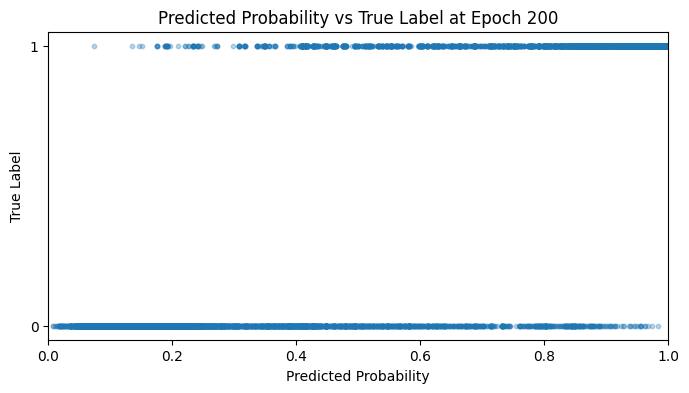


===== Fold 4/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.15886250
  P1-H1-P2-H2: 0.16291600
  P-D-P: 0.20163397
  H1-PD-H2: 0.15886250
  PH1-D-PH2: 0.15886250
  HH1-D-HH2: 0.15886250

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5215, 最大值: 0.5425, 均值: 0.5285
[真实为1] 样本数: 4393, 最小值: 0.5233, 最大值: 0.5469, 均值: 0.5320
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6793 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7368
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.09725756
  P1-H1-P2-H2: 0.09407383
  P-D-P: 0.51689589
  H1-PD-H2: 0.09725756
  PH1-D-PH2: 0.09725756
  HH1-D-HH2: 0.09725756

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5578, 最大值: 0.8001, 均值: 0.6114
[真实为1] 样本数: 4393, 最小值: 0.5731, 最大值: 0.8693, 均值: 0.6672
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6218 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7864
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.10065759
  P1-H1-P2-H2: 0.02426773
  P-D-P: 0.57310188
  H1-PD-H2: 0.10065759
  PH1-D-PH2: 0.10065759
  HH1-D-HH2: 0.10065759

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5177, 最大值: 0.7761, 均值: 0.5653
[真实为1] 样本数: 4393, 最小值: 0.5346, 最大值: 0.8557, 均值: 0.6388
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5856 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8425
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.08874982
  P1-H1-P2-H2: 0.01312367
  P-D-P: 0.63187701
  H1-PD-H2: 0.08874982
  PH1-D-PH2: 0.08874982
  HH1-D-HH2: 0.08874982

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4439, 最大值: 0.8010, 均值: 0.5304
[真实为1] 样本数: 4393, 最小值: 0.4996, 最大值: 0.9066, 均值: 0.6320
thresh=0.500,checkcost=0.06, cost_fn=0.035, cost_fp=308.760, cost_tp=210.816, cost_with=519.611, cost_without=602.004, savings=0.1369, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0801
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5595 | Acc: 0.5283 | Precision: 0.4605 | Recall: 0.9998 | F1: 0.6305 | ROC AUC: 0.8768
Confusion Matrix:
 [[1373 5146]
 [   1 4392]]
Savings: 0.1369

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.04740436
  P1-H1-P2-H2: 0.00726400
  P-D-P: 0.80311859
  H1-PD-H2: 0.04740436
  PH1-D-PH2: 0.04740436
  HH1-D-HH2: 0.04740436

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.2559, 最大值: 0.8351, 均值: 0.4798
[真实为1] 样本数: 43

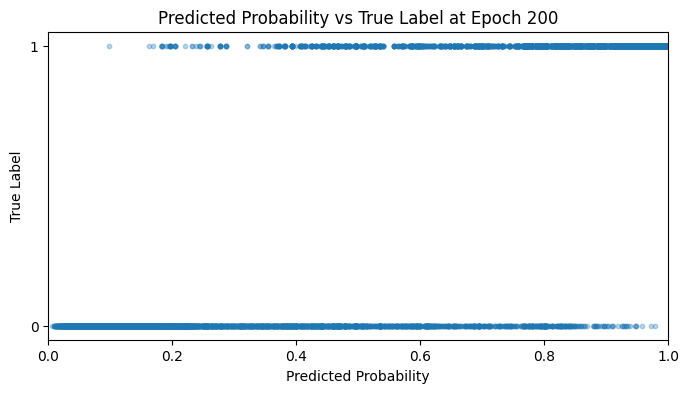


===== Fold 5/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.17054105
  P1-H1-P2-H2: 0.16606037
  P-D-P: 0.15177551
  H1-PD-H2: 0.17054105
  PH1-D-PH2: 0.17054105
  HH1-D-HH2: 0.17054105

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5050, 最大值: 0.5217, 均值: 0.5101
[真实为1] 样本数: 4393, 最小值: 0.5037, 最大值: 0.5214, 均值: 0.5111
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6943 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.5925
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.10507409
  P1-H1-P2-H2: 0.20368296
  P-D-P: 0.37602073
  H1-PD-H2: 0.10507409
  PH1-D-PH2: 0.10507409
  HH1-D-HH2: 0.10507409

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5571, 最大值: 0.8060, 均值: 0.6199
[真实为1] 样本数: 4393, 最小值: 0.5622, 最大值: 0.8615, 均值: 0.6644
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6301 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7394
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.09803207
  P1-H1-P2-H2: 0.03850333
  P-D-P: 0.56936836
  H1-PD-H2: 0.09803207
  PH1-D-PH2: 0.09803207
  HH1-D-HH2: 0.09803207

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5155, 最大值: 0.7621, 均值: 0.5606
[真实为1] 样本数: 4393, 最小值: 0.5303, 最大值: 0.8288, 均值: 0.6259
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5889 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8183
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.08377544
  P1-H1-P2-H2: 0.01444246
  P-D-P: 0.65045577
  H1-PD-H2: 0.08377544
  PH1-D-PH2: 0.08377544
  HH1-D-HH2: 0.08377544

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4326, 最大值: 0.8079, 均值: 0.5312
[真实为1] 样本数: 4393, 最小值: 0.4954, 最大值: 0.9210, 均值: 0.6325
thresh=0.500,checkcost=0.06, cost_fn=0.068, cost_fp=295.680, cost_tp=210.768, cost_with=506.516, cost_without=602.004, savings=0.1586, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0822
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5595 | Acc: 0.5482 | Precision: 0.4712 | Recall: 0.9995 | F1: 0.6405 | ROC AUC: 0.8612
Confusion Matrix:
 [[1591 4928]
 [   2 4391]]
Savings: 0.1586

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.04599373
  P1-H1-P2-H2: 0.00507946
  P-D-P: 0.81094569
  H1-PD-H2: 0.04599373
  PH1-D-PH2: 0.04599373
  HH1-D-HH2: 0.04599373

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.2231, 最大值: 0.8529, 均值: 0.4833
[真实为1] 样本数: 43

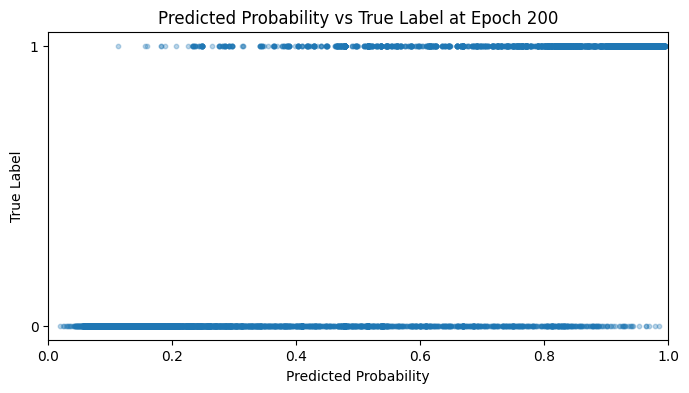


===== Fold 6/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.17193538
  P1-H1-P2-H2: 0.13577668
  P-D-P: 0.17648183
  H1-PD-H2: 0.17193538
  PH1-D-PH2: 0.17193538
  HH1-D-HH2: 0.17193538

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5160, 最大值: 0.5346, 均值: 0.5207
[真实为1] 样本数: 4393, 最小值: 0.5184, 最大值: 0.5367, 均值: 0.5245
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6828 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8086
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.09822930
  P1-H1-P2-H2: 0.05391116
  P-D-P: 0.55317158
  H1-PD-H2: 0.09822930
  PH1-D-PH2: 0.09822930
  HH1-D-HH2: 0.09822930

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5548, 最大值: 0.8321, 均值: 0.6166
[真实为1] 样本数: 4393, 最小值: 0.5737, 最大值: 0.8840, 均值: 0.6798
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6181 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7826
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.11349951
  P1-H1-P2-H2: 0.01596950
  P-D-P: 0.53003246
  H1-PD-H2: 0.11349951
  PH1-D-PH2: 0.11349951
  HH1-D-HH2: 0.11349951

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5168, 最大值: 0.7533, 均值: 0.5589
[真实为1] 样本数: 4393, 最小值: 0.5334, 最大值: 0.8206, 均值: 0.6220
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5897 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8407
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.09590340
  P1-H1-P2-H2: 0.00639835
  P-D-P: 0.60998803
  H1-PD-H2: 0.09590340
  PH1-D-PH2: 0.09590340
  HH1-D-HH2: 0.09590340

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4793, 最大值: 0.8059, 均值: 0.5473
[真实为1] 样本数: 4393, 最小值: 0.5150, 最大值: 0.9056, 均值: 0.6405
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=388.860, cost_tp=210.864, cost_with=599.724, cost_without=602.004, savings=0.0038, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0694
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5662 | Acc: 0.4061 | Precision: 0.4040 | Recall: 1.0000 | F1: 0.5755 | ROC AUC: 0.8662
Confusion Matrix:
 [[  38 6481]
 [   0 4393]]
Savings: 0.0038

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.06330290
  P1-H1-P2-H2: 0.00345440
  P-D-P: 0.74333400
  H1-PD-H2: 0.06330290
  PH1-D-PH2: 0.06330290
  HH1-D-HH2: 0.06330290

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3490, 最大值: 0.8440, 均值: 0.5176
[真实为1] 样本数: 43

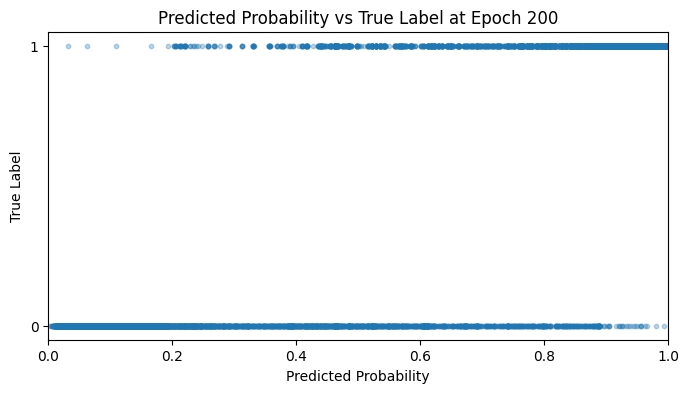


===== Fold 7/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.16651225
  P1-H1-P2-H2: 0.15298276
  P-D-P: 0.18096823
  H1-PD-H2: 0.16651225
  PH1-D-PH2: 0.16651225
  HH1-D-HH2: 0.16651225

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5148, 最大值: 0.5294, 均值: 0.5194
[真实为1] 样本数: 4393, 最小值: 0.5171, 最大值: 0.5347, 均值: 0.5229
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6845 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8223
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.09775873
  P1-H1-P2-H2: 0.09095777
  P-D-P: 0.51800734
  H1-PD-H2: 0.09775873
  PH1-D-PH2: 0.09775873
  HH1-D-HH2: 0.09775873

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5600, 最大值: 0.8165, 均值: 0.6179
[真实为1] 样本数: 4393, 最小值: 0.5768, 最大值: 0.8748, 均值: 0.6782
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6202 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7854
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.09805338
  P1-H1-P2-H2: 0.02352339
  P-D-P: 0.58426315
  H1-PD-H2: 0.09805338
  PH1-D-PH2: 0.09805338
  HH1-D-HH2: 0.09805338

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5171, 最大值: 0.7472, 均值: 0.5586
[真实为1] 样本数: 4393, 最小值: 0.5323, 最大值: 0.8405, 均值: 0.6228
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5905 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8397
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.08079303
  P1-H1-P2-H2: 0.01007011
  P-D-P: 0.66675782
  H1-PD-H2: 0.08079303
  PH1-D-PH2: 0.08079303
  HH1-D-HH2: 0.08079303

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4368, 最大值: 0.7915, 均值: 0.5341
[真实为1] 样本数: 4393, 最小值: 0.5013, 最大值: 0.9082, 均值: 0.6276
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=335.340, cost_tp=210.864, cost_with=546.204, cost_without=602.004, savings=0.0927, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0762
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5642 | Acc: 0.4878 | Precision: 0.4401 | Recall: 1.0000 | F1: 0.6112 | ROC AUC: 0.8653
Confusion Matrix:
 [[ 930 5589]
 [   0 4393]]
Savings: 0.0927

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.04615870
  P1-H1-P2-H2: 0.00484743
  P-D-P: 0.81051773
  H1-PD-H2: 0.04615870
  PH1-D-PH2: 0.04615870
  HH1-D-HH2: 0.04615870

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.2504, 最大值: 0.8313, 均值: 0.4872
[真实为1] 样本数: 43

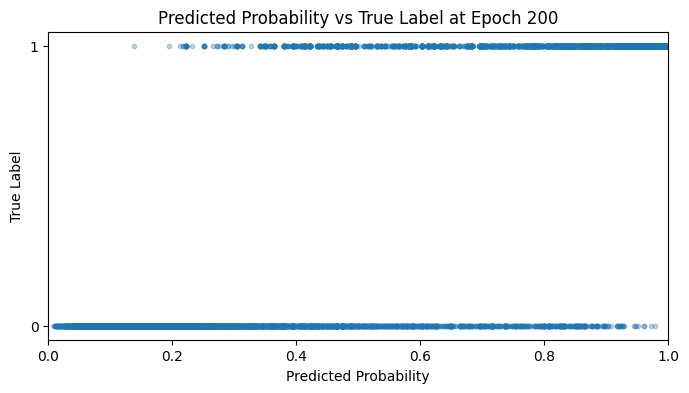


===== Fold 8/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.16190128
  P1-H1-P2-H2: 0.19665988
  P-D-P: 0.15573503
  H1-PD-H2: 0.16190128
  PH1-D-PH2: 0.16190128
  HH1-D-HH2: 0.16190128

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4978, 最大值: 0.5159, 均值: 0.5030
[真实为1] 样本数: 4393, 最小值: 0.5001, 最大值: 0.5182, 均值: 0.5061
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=376.260, cost_tp=210.864, cost_with=587.124, cost_without=602.004, savings=0.0247, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0709
0.0000 < check < 0.0692

Epoch 001 | Loss: 0.6996 | Acc: 0.4253 | Precision: 0.4119 | Recall: 1.0000 | F1: 0.5835 | ROC AUC: 0.8084
Confusion Matrix:
 [[ 248 6271]
 [   0 4393]]
Savings: 0.0247

Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.09771340
  P1-H1-P2-H2: 0.18563682
  P-D-P: 0.42350954
  H1-PD-H2: 0.09771340
 

/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.10311750
  P1-H1-P2-H2: 0.03902349
  P-D-P: 0.54850650
  H1-PD-H2: 0.10311750
  PH1-D-PH2: 0.10311750
  HH1-D-HH2: 0.10311750

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5083, 最大值: 0.7704, 均值: 0.5540
[真实为1] 样本数: 4393, 最小值: 0.5257, 最大值: 0.8324, 均值: 0.6267
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5827 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8417
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.09411072
  P1-H1-P2-H2: 0.01605327
  P-D-P: 0.60750383
  H1-PD-H2: 0.09411072
  PH1-D-PH2: 0.09411072
  HH1-D-HH2: 0.09411072

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4339, 最大值: 0.8076, 均值: 0.5301
[真实为1] 样本数: 4393, 最小值: 0.4970, 最大值: 0.8938, 均值: 0.6325
thresh=0.500,checkcost=0.06, cost_fn=0.068, cost_fp=292.260, cost_tp=210.768, cost_with=503.096, cost_without=602.004, savings=0.1643, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0828
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5572 | Acc: 0.5534 | Precision: 0.4741 | Recall: 0.9995 | F1: 0.6431 | ROC AUC: 0.8692
Confusion Matrix:
 [[1648 4871]
 [   2 4391]]
Savings: 0.1643

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.06817103
  P1-H1-P2-H2: 0.00796879
  P-D-P: 0.71934712
  H1-PD-H2: 0.06817103
  PH1-D-PH2: 0.06817103
  HH1-D-HH2: 0.06817103

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.2961, 最大值: 0.8351, 均值: 0.4941
[真实为1] 样本数: 43

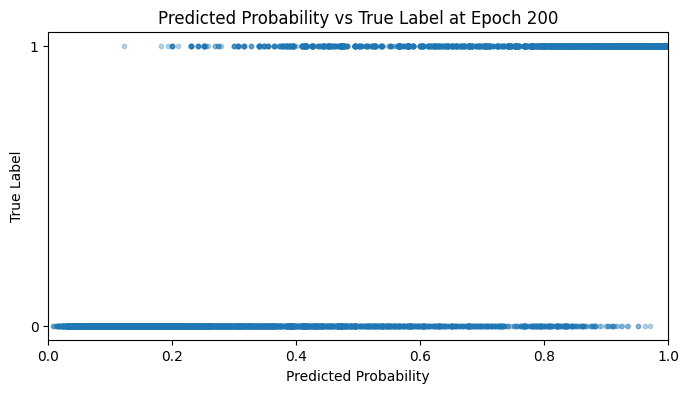


===== Fold 9/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.17324294
  P1-H1-P2-H2: 0.13853343
  P-D-P: 0.16849478
  H1-PD-H2: 0.17324294
  PH1-D-PH2: 0.17324294
  HH1-D-HH2: 0.17324294

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5089, 最大值: 0.5188, 均值: 0.5122
[真实为1] 样本数: 4393, 最小值: 0.5103, 最大值: 0.5202, 均值: 0.5140
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6915 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7800
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.10699498
  P1-H1-P2-H2: 0.15100774
  P-D-P: 0.42101237
  H1-PD-H2: 0.10699498
  PH1-D-PH2: 0.10699498
  HH1-D-HH2: 0.10699498

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5585, 最大值: 0.8160, 均值: 0.6174
[真实为1] 样本数: 4393, 最小值: 0.5705, 最大值: 0.8709, 均值: 0.6705
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6229 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7715
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.11191503
  P1-H1-P2-H2: 0.03401747
  P-D-P: 0.51832235
  H1-PD-H2: 0.11191503
  PH1-D-PH2: 0.11191503
  HH1-D-HH2: 0.11191503

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5146, 最大值: 0.7560, 均值: 0.5566
[真实为1] 样本数: 4393, 最小值: 0.5299, 最大值: 0.8143, 均值: 0.6192
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5909 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8326
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.09575395
  P1-H1-P2-H2: 0.01349960
  P-D-P: 0.60348463
  H1-PD-H2: 0.09575395
  PH1-D-PH2: 0.09575395
  HH1-D-HH2: 0.09575395

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.4747, 最大值: 0.8155, 均值: 0.5449
[真实为1] 样本数: 4393, 最小值: 0.5097, 最大值: 0.8883, 均值: 0.6421
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=381.540, cost_tp=210.864, cost_with=592.404, cost_without=602.004, savings=0.0159, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0703
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5656 | Acc: 0.4172 | Precision: 0.4086 | Recall: 1.0000 | F1: 0.5801 | ROC AUC: 0.8583
Confusion Matrix:
 [[ 160 6359]
 [   0 4393]]
Savings: 0.0159

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.07164021
  P1-H1-P2-H2: 0.00771678
  P-D-P: 0.70572245
  H1-PD-H2: 0.07164021
  PH1-D-PH2: 0.07164021
  HH1-D-HH2: 0.07164021

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3307, 最大值: 0.8499, 均值: 0.5124
[真实为1] 样本数: 43

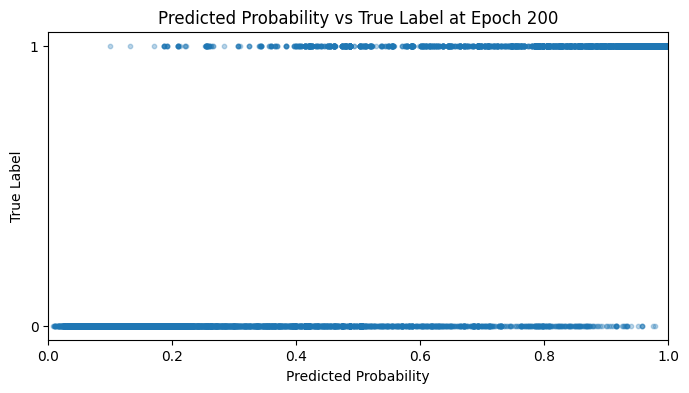


===== Fold 10/10 =====
[INFO] Using device: cuda
Labels unique: tensor([0, 1], device='cuda:0')
Train mask sum: 9821
Test mask sum: 1091

Epoch 001 - 平均元路径注意力:
  P1-HD-P2: 0.15909107
  P1-H1-P2-H2: 0.19982374
  P-D-P: 0.16381201
  H1-PD-H2: 0.15909107
  PH1-D-PH2: 0.15909107
  HH1-D-HH2: 0.15909107

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5210, 最大值: 0.5617, 均值: 0.5307
[真实为1] 样本数: 4393, 最小值: 0.5225, 最大值: 0.5634, 均值: 0.5347
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 001 | Loss: 0.6767 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7095
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 010 - 平均元路径注意力:
  P1-HD-P2: 0.09804329
  P1-H1-P2-H2: 0.15079096
  P-D-P: 0.45703587
  H1-PD-H2: 0.09804329
  PH1-D-PH2: 0.09804329
  HH1-D-HH2: 0.09804329

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5563, 最大值: 0.8067, 均值: 0.6111
[真实为1] 样本数: 4393, 最小值: 0.5721, 最大值: 0.8594, 均值: 0.6662
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 010 | Loss: 0.6207 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.7818
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 020 - 平均元路径注意力:
  P1-HD-P2: 0.08703017
  P1-H1-P2-H2: 0.04360525
  P-D-P: 0.60827410
  H1-PD-H2: 0.08703017
  PH1-D-PH2: 0.08703017
  HH1-D-HH2: 0.08703017

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.5122, 最大值: 0.8110, 均值: 0.5668
[真实为1] 样本数: 4393, 最小值: 0.5333, 最大值: 0.8687, 均值: 0.6491
thresh=0.500,checkcost=0.06, cost_fn=0.000, cost_fp=391.140, cost_tp=210.864, cost_with=602.004, cost_without=602.004, savings=0.0000, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0692
nan < check < 0.0692

Epoch 020 | Loss: 0.5803 | Acc: 0.4026 | Precision: 0.4026 | Recall: 1.0000 | F1: 0.5741 | ROC AUC: 0.8493
Confusion Matrix:
 [[   0 6519]
 [   0 4393]]
Savings: 0.0000


/tmp/ipython-input-1613355763.py:56: RuntimeWarning: invalid value encountered in scalar divide
  thresh_2 = sample_cost[(labels==1) & (predictions==0)].sum() / (



Epoch 030 - 平均元路径注意力:
  P1-HD-P2: 0.06898927
  P1-H1-P2-H2: 0.03088721
  P-D-P: 0.69315577
  H1-PD-H2: 0.06898927
  PH1-D-PH2: 0.06898927
  HH1-D-HH2: 0.06898927

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.3987, 最大值: 0.8462, 均值: 0.5319
[真实为1] 样本数: 4393, 最小值: 0.4922, 最大值: 0.9388, 均值: 0.6514
thresh=0.500,checkcost=0.06, cost_fn=0.068, cost_fp=275.820, cost_tp=210.768, cost_with=486.656, cost_without=602.004, savings=0.1916, cost_all_pos=602.0040, cost_all_neg=694.0346
有标签为0的样本总数：6519
有标签为1的样本总数：4393
middle_threash: 0.0692
0.0692 < check < 0.0856
0.0000 < check < 0.0692

Epoch 030 | Loss: 0.5512 | Acc: 0.5785 | Precision: 0.4885 | Recall: 0.9995 | F1: 0.6563 | ROC AUC: 0.8810
Confusion Matrix:
 [[1922 4597]
 [   2 4391]]
Savings: 0.1916

Epoch 040 - 平均元路径注意力:
  P1-HD-P2: 0.03083317
  P1-H1-P2-H2: 0.02412216
  P-D-P: 0.85254514
  H1-PD-H2: 0.03083317
  PH1-D-PH2: 0.03083317
  HH1-D-HH2: 0.03083317

=== 概率分布分析（测试集） ===
[真实为0] 样本数: 6519, 最小值: 0.1798, 最大值: 0.8731, 均值: 0.4671
[真实为1] 样本数: 43

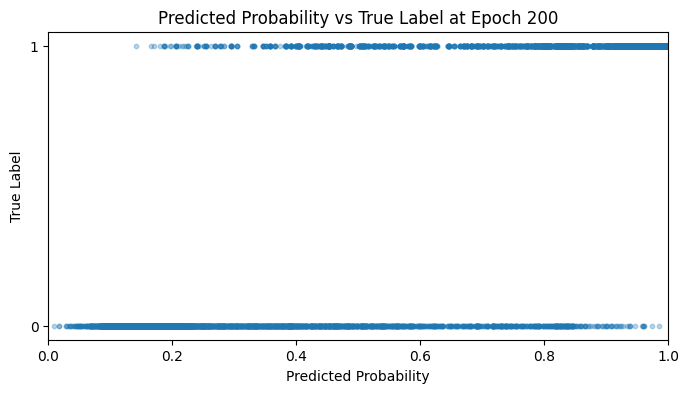


===== Cross-validation 结果 =====
Accuracy: mean=0.8999, max=0.9058, min=0.8918, std=0.0035, range=0.0140
Precision: mean=0.8455, max=0.8556, min=0.8255, std=0.0089, range=0.0301
Recall: mean=0.9194, max=0.9306, min=0.9069, std=0.0072, range=0.0237
F1: mean=0.8809, max=0.8873, min=0.8734, std=0.0036, range=0.0140
AUCROC: mean=0.9730, max=0.9752, min=0.9703, std=0.0016, range=0.0049
Savings: mean=0.5696, max=0.5758, min=0.5624, std=0.0037, range=0.0134


In [ ]:
## 耦合 训练评估函数

import torch
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GATConv
from torch.nn import Parameter
from sklearn.model_selection import KFold

def cross_validate_with_std(model_class, data, sample_cost_train, sample_cost_test,
                            loss_fn, optimizer_fn, savings_fn, metapaths, metapath_names,
                            check_cost, Lambda, epochs=100, k=10, device="cpu"):
    labels = data['patient'].y.cpu().numpy()
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    accs, precs, recs, f1s, aucs, savs = [], [], [], [], [], []


    for fold, (train_idx, test_idx) in enumerate(kf.split(labels)):
        print(f"\n===== Fold {fold+1}/{k} =====")

        train_mask = torch.zeros(len(labels), dtype=torch.bool)
        test_mask = torch.zeros(len(labels), dtype=torch.bool)
        train_mask[train_idx] = True
        test_mask[test_idx] = True

            # 截取每折对应的成本向量
        sample_cost_train_fold = sample_cost_train[train_idx]
        sample_cost_test_fold = sample_cost_test[test_idx]


        model = model_class(data.metadata, metapaths, hidden_channels=64, out_channels=1,
                            num_gat_layers=2, heads=4, concat=True).to(device)
        optimizer = optimizer_fn(model.parameters())

        # 调用你的主函数
        metrics = train_and_evaluate(model, data, train_mask, test_mask,

                                      sample_cost_np=sample_cost_test_fold,
                                      sample_cost_train=sample_cost_train_fold,

                                     optimizer=optimizer,
                                     loss_fn=loss_fn,
                                     device=device,
                                     epochs=epochs,
                                     threshold=0.5,
                                     check_cost=check_cost,
                                     Lambda=Lambda,
                                     metapaths=metapaths,
                                     metapath_names=metapath_names,
                                     savings=savings_fn)

        #  metrics
        accs.append(metrics["accuracy"])
        precs.append(metrics["precision"])
        recs.append(metrics["recall"])
        f1s.append(metrics["f1"])
        aucs.append(metrics["aucroc"])
        savs.append(metrics["savings"])


    def summary_stats(values):
      return {
          "mean": np.mean(values),
          "max": np.max(values),
          "min": np.min(values),
          "std": np.std(values),
          "range": np.ptp(values)
      }

    print("\n===== Cross-validation 结果 =====")
    for name, vals in {
        "Accuracy": accs,
        "Precision": precs,
        "Recall": recs,
        "F1": f1s,
        "AUCROC": aucs,
        "Savings": savs
    }.items():
        stats = summary_stats(vals)
        print(f"{name}: mean={stats['mean']:.4f}, max={stats['max']:.4f}, "
              f"min={stats['min']:.4f}, std={stats['std']:.4f}, range={stats['range']:.4f}")
    print("="*40)


cross_validate_with_std(
    model_class=HANModel,
    data=data,

    sample_cost_train=sample_cost_full,
    sample_cost_test=sample_cost_full,
    loss_fn=hybrid_cost_bce_loss,

    optimizer_fn=lambda params: torch.optim.Adam(params, lr=0.0005),
    savings_fn=savings,
    metapaths=metapaths,
    metapath_names=metapath_names,
    check_cost=0.06,
    Lambda=0.8,
    epochs=200,
    k=10,
    device=DEVICE
)



In [ ]:
# ======= 保存到 CSV（每列包含：超参 + 指标 + 每条元路径注意力）=======
df_results = pd.DataFrame(results)
print("\nGrid Search 全部结果：")
print(df_results)

df_results.to_csv(r"/content/drive/MyDrive/Colab Notebooks/gridsearch_results_with_attention.csv", index=False)
print("✅ 已保存到 gridsearch_results_with_attention.csv")


Grid Search 全部结果：
     hidden_channels  heads      lr  num_gat_layers       acc  precision  \
0                 64      2  0.0001               1  0.406891   0.404025   
1                 64      2  0.0001               2  0.402584   0.402584   
2                 64      2  0.0001               3  0.597324   0.333333   
3                 64      2  0.0001               4  0.527951   0.460231   
4                 64      2  0.0005               1  0.525660   0.447779   
..               ...    ...     ...             ...       ...        ...   
109              128      8  0.0001               2  0.836694   0.713981   
110              128      8  0.0001               3  0.402401   0.401170   
111              128      8  0.0001               4  0.831195   0.706358   
112              128     16  0.0001               1  0.534091   0.450734   
113              128     16  0.0001               2  0.855389   0.737633   

       recall        f1   roc_auc    savings     P-H-P     P-D-P    

In [ ]:
results

[{'hidden_channels': 64,
  'heads': 2,
  'lr': 0.0001,
  'num_gat_layers': 1,
  'acc': 0.40689149560117305,
  'precision': 0.40402548241159636,
  'recall': 0.996130207147735,
  'f1': 0.5748817656332107,
  'roc_auc': np.float64(0.5029738319064339),
  'savings': np.float64(-0.04222982369967321),
  'P-H-P': 0.0,
  'P-D-P': 0.011455278843641281,
  'D-P-D': 0.5472874045372009,
  'H-P-H': 0.4412573277950287,
  'P1-H1-P2-H2': 0.0,
  'P1-D1-P2-D2': 0.0,
  'P1-HD-P2': 0.0,
  'H1-PD-H2': 0.0,
  'PH1-D-PH2': 0.0,
  'HH1-D-HH2': 0.0},
 {'hidden_channels': 64,
  'heads': 2,
  'lr': 0.0001,
  'num_gat_layers': 2,
  'acc': 0.4025843108504399,
  'precision': 0.4025843108504399,
  'recall': 1.0,
  'f1': 0.5740607644560601,
  'roc_auc': np.float64(0.826523666990747),
  'savings': np.float64(0.0),
  'P-H-P': 0.016738291829824448,
  'P-D-P': 0.5430701375007629,
  'D-P-D': 0.02876058779656887,
  'H-P-H': 0.015171078965067863,
  'P1-H1-P2-H2': 0.02989976480603218,
  'P1-D1-P2-D2': 0.26340916752815247,
  'P1